In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

import h5py

from deep_lss.utils import emulator, abc
from msfm.utils import prior

print(tf.config.list_physical_devices())

23-03-24 03:57:36     utils.py INF   Loaded the config 
23-03-24 03:57:36   kernels.py INF   Setting the minimum value of the kernel function to 1e-42 for the mpmath library 
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:2', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:3', device_type='GPU')]


In [2]:
preds_file = "/pscratch/sd/a/athomsen/run_files/2023-03-13_06-27-46_resnet_small/preds.h5"

with h5py.File(preds_file, "r") as f:
    print(f.keys())
    
    grid_preds = f["grid/preds"][:]
    grid_cosmos = f["grid/cosmos"][:]
    
    fidu_preds = f["fiducial/preds"][:]

# remove the unwanted axis
if np.all([np.equal(grid_cosmos[:,i,:], grid_cosmos[:,i+1,:]) for i in range(grid_cosmos.shape[1]-1)]):
    grid_cosmos = grid_cosmos[:,0,:]
else:
    raise Error
    
print(grid_preds.shape)
print(grid_cosmos.shape)

print(fidu_preds.shape)

<KeysViewHDF5 ['fiducial', 'grid']>
(2500, 16, 2)
(2500, 7)
(800, 2)


# Estimate the ABC posterior

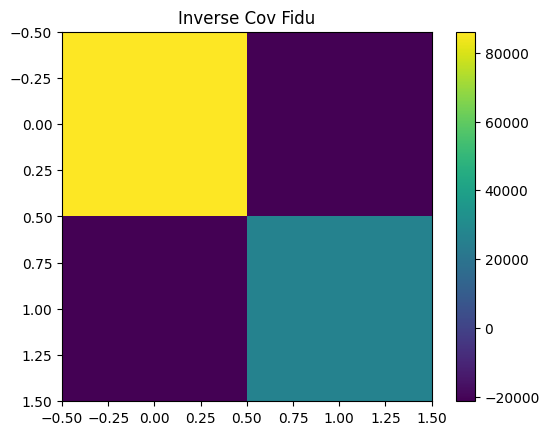

1.0


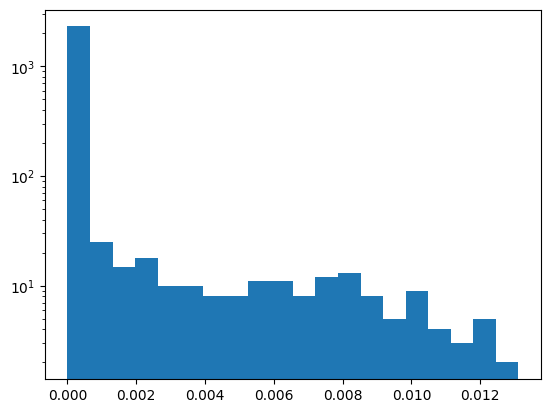

In [3]:
# kernel params
kernel = "sigmoid"
scale=0.5

# get an approximation to the Fisher  matrix
fid_inv_cov = np.linalg.inv(np.cov(fidu_preds, rowvar=False))

# check the inverse covariance
plt.imshow(fid_inv_cov)
plt.colorbar()
plt.title("Inverse Cov Fidu")
plt.show()

# TODO make a distinction between validation and fiducial prediction
obs_pred = np.mean(fidu_preds, axis=0)

# Estimate the posterior and its uncertainties like in the paper
Y_init, abc_posterior = abc.estimate_grid_posterior(
    grid_preds=grid_preds, 
    fid_fisher=fid_inv_cov, 
    obs_pred=obs_pred, 
    scale=scale, 
    kernel=kernel
)

# check posterior
print(np.sum(abc_posterior))
plt.hist(abc_posterior, log=True, bins=20);

### analyze the ABC posterior

[Text(0.5, 1.0, 'log posterior variance')]

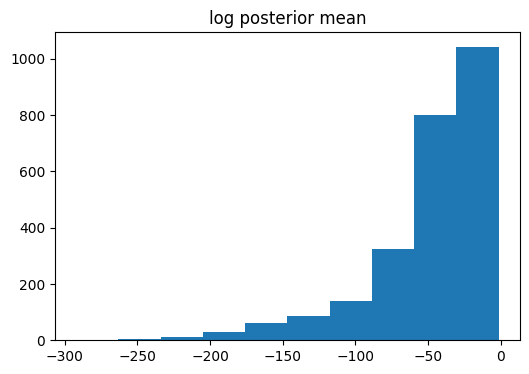

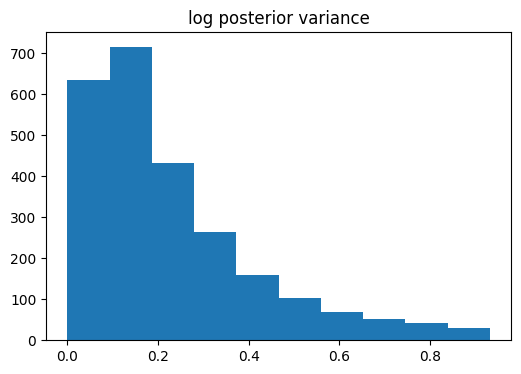

In [4]:
# change variance
# Y_init[:,1] = 1000*Y_init[:,1]
# Y_init[:,1] = 0.01*Y_init[:,1]

# log posterior mean
fig, ax = plt.subplots(figsize=(6,4))

ax.hist(Y_init[:,0])
ax.set(title="log posterior mean")

# log posterior variance
fig, ax = plt.subplots(figsize=(6,4))

ax.hist(Y_init[:,1])
ax.set(title="log posterior variance")

### select correct cosmological parameters

In [5]:
for i in range(grid_cosmos.shape[1]):
    print(i, np.min(grid_cosmos[:,i]), "      ", np.max(grid_cosmos[:,i]))
    
Om = grid_cosmos[:,2]
s8 = grid_cosmos[:,4]

0 64.004395        81.98682
1 0.030029297        0.059970703
2 0.10039063        0.49990234
3 0.87009764        1.0699023
4 0.40024415        1.3973144
5 -1.9348828        -0.33381397
6 -2.9970703        2.999977


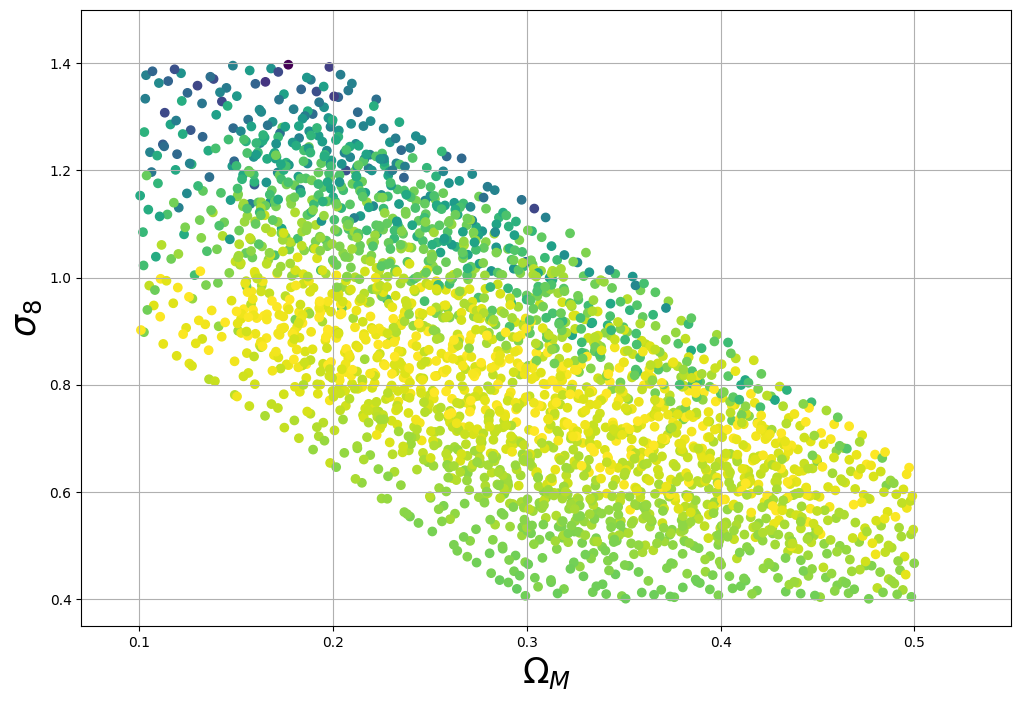

In [6]:
fig, ax = plt.subplots(figsize=(12,8))
ax.scatter(Om, s8, c=Y_init[:,0])
ax.set(xlim=(0.07, 0.55), ylim=(0.35, 1.5))
ax.set_xlabel("$\Omega_M$", fontsize=25)
ax.set_ylabel("$\sigma_8$", fontsize=25)
ax.grid(True)

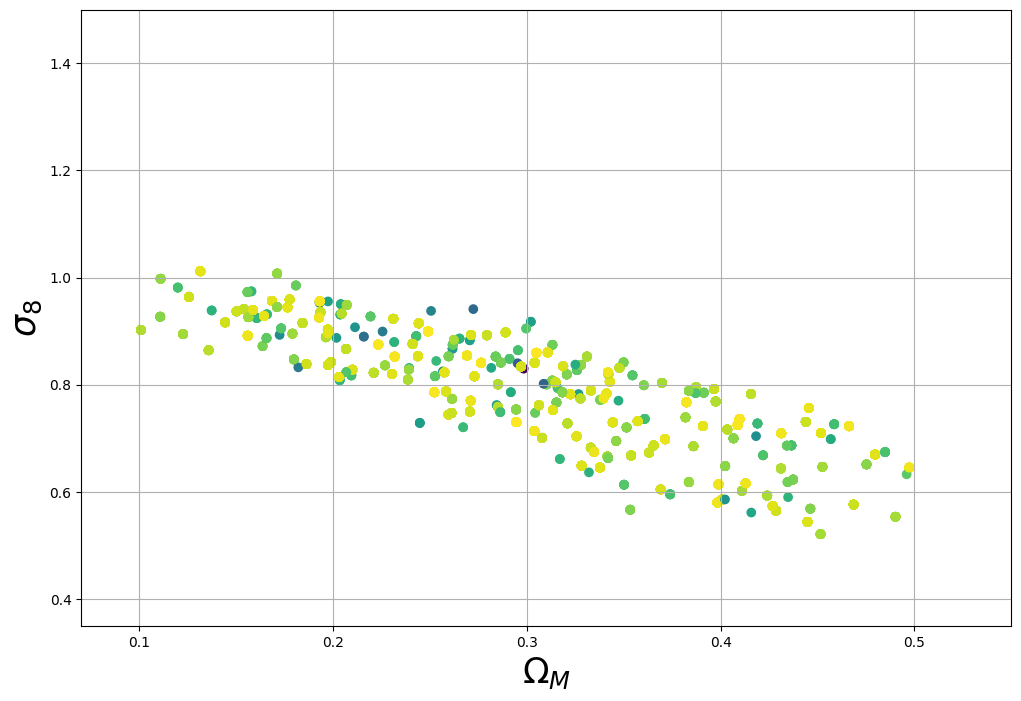

In [7]:
# select a random subset
np.random.seed(11)
probable_indices = np.random.choice(np.arange(len(abc_posterior)), 5000, p=abc_posterior, replace=True)

Om_p, s8_p, post_p = Om[probable_indices], s8[probable_indices], abc_posterior[probable_indices],

fig, ax = plt.subplots(figsize=(12,8))
ax.scatter(Om_p, s8_p, c=np.log(post_p))
ax.set(xlim=(0.07, 0.55), ylim=(0.35, 1.5))
ax.set_xlabel("$\Omega_M$", fontsize=25)
ax.set_ylabel("$\sigma_8$", fontsize=25)
ax.grid(True)

# Fit the GP emulator

In [8]:
X_init = np.stack([Om, s8], axis=-1)
X_init.shape

(2500, 2)

In [9]:
emu = emulator.VGP_Emu(
    X_init=X_init[:500], 
    Y_init=Y_init[:500], 
    kernel_type="squaredexponential", 
    normalize_X=True, 
    normalize_Y=True,
    Y_with_std=True, 
    ARD=True, 
)

╒═════════════════════════╤═══════════╤════════════════╤═════════╤═════════════╤═══════════════╤═════════╤══════════════════╕
│ name                    │ class     │ transform      │ prior   │ trainable   │ shape         │ dtype   │ value            │
╞═════════════════════════╪═══════════╪════════════════╪═════════╪═════════════╪═══════════════╪═════════╪══════════════════╡
│ VGP.kernel.variance     │ Parameter │ Softplus       │         │ True        │ ()            │ float64 │ 1.0              │
├─────────────────────────┼───────────┼────────────────┼─────────┼─────────────┼───────────────┼─────────┼──────────────────┤
│ VGP.kernel.lengthscales │ Parameter │ Softplus       │         │ True        │ (2,)          │ float64 │ [1. 1.]          │
├─────────────────────────┼───────────┼────────────────┼─────────┼─────────────┼───────────────┼─────────┼──────────────────┤
│ VGP.num_data            │ Parameter │ Identity       │         │ False       │ ()            │ int32   │ 500        

2023-03-24 03:57:40.711265: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-03-24 03:57:42.507816: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38277 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:03:00.0, compute capability: 8.0
2023-03-24 03:57:42.509087: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 38277 MB memory:  -> device: 1, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:41:00.0, compute capability: 8.0
2023-03-24 03:57:42.510211: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/devi

In [10]:
emu.repeated_fit(n_steps=1000, n_restarts=1)

  0%|                            |   | 0/1000 [00:00<?, ?it/s]                fit the GP

2023-03-24 03:57:44.812887: I tensorflow/core/util/cuda_solvers.cc:179] Creating GpuSolver handles for stream 0x345b70b0


100%|████████████████████████████|   | 1000/1000 [00:31<00:00, 31.43it/s, loss_val=5.54e+4] fit the GP
23-03-24 03:58:14  emulator.py INF   Training run 0: loss = 55397.149166123425 
23-03-24 03:58:14  emulator.py INF   Training run 0 was best, setting those parameters 
╒═════════════════════════╤═══════════╤════════════════╤═════════╤═════════════╤═══════════════╤═════════╤══════════════════════════════════════════╕
│ name                    │ class     │ transform      │ prior   │ trainable   │ shape         │ dtype   │ value                                    │
╞═════════════════════════╪═══════════╪════════════════╪═════════╪═════════════╪═══════════════╪═════════╪══════════════════════════════════════════╡
│ VGP.kernel.variance     │ Parameter │ Softplus       │         │ True        │ ()            │ float64 │ 1.03963                                  │
├─────────────────────────┼───────────┼────────────────┼─────────┼─────────────┼───────────────┼─────────┼───────────────────────

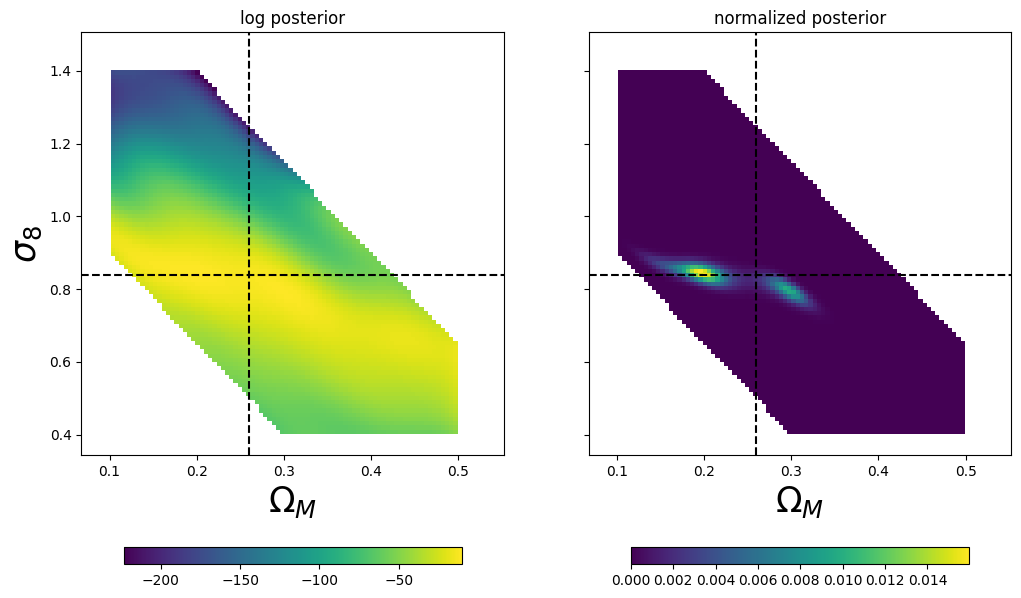

In [11]:
resolution = 100

Om_lin = np.linspace(0.07, 0.55, resolution)
s8_lin = np.linspace(0.35, 1.5, resolution)

# full coordinate arrays
Om_grid, s8_grid = np.meshgrid(Om_lin, s8_lin)

X = np.stack([Om_grid.ravel(), s8_grid.ravel()], axis=1)

log_posterior = emu(X)

# enforce the prior
in_prior = prior.in_grid_prior(X, params=["Om", "s8"])
log_posterior[~in_prior] = -np.inf

# reshape for the plot
log_posterior = log_posterior.reshape(resolution, resolution)

fig, ax = plt.subplots(figsize=(12,8), ncols=2, sharey=True)         

# log posterior
im = ax[0].pcolormesh(Om_lin, s8_lin, log_posterior)
fig.colorbar(im, orientation="horizontal", shrink=0.8)
ax[0].set(title="log posterior", xlabel="$\Omega_M$", ylabel="$\sigma_8$")
ax[0].set_xlabel("$\Omega_M$", fontsize=25)
ax[0].set_ylabel("$\sigma_8$", fontsize=25)
ax[0].set_box_aspect(1)
ax[0].axvline(0.26, color="k", linestyle="--")
ax[0].axhline(0.84, color="k", linestyle="--")

# normalized posterior
log_posterior -= np.max(log_posterior)
posterior = np.exp(log_posterior)
posterior /= np.sum(posterior)
posterior = np.ma.masked_array(posterior, ~in_prior.reshape(resolution, resolution))

im = ax[1].pcolormesh(Om_lin, s8_lin, posterior)
fig.colorbar(im, orientation="horizontal", shrink=0.8)
ax[1].set(title="normalized posterior")
ax[1].set_xlabel("$\Omega_M$", fontsize=25)
ax[1].set_box_aspect(1)
ax[1].axvline(0.26, color="k", linestyle="--")
ax[1].axhline(0.84, color="k", linestyle="--")

# # S8
# S8 = s8*np.sqrt(Om/0.3)
# S8_lin = np.linspace(S8.min(), S8.max(), resolution)

# Om_mod = S8_lin**2/s8_lin**2 * 0.3
# s8_mod = S8_lin/np.sqrt(Om_lin/0.3)

# Om_grid, s8_grid = np.meshgrid(Om_lin, s8_lin)
# X = np.stack([Om_grid.ravel(), s8_grid.ravel()], axis=1)

# log_posterior = emu(X)

# im = ax[2].pcolormesh(Om_lin, s8_lin, log_posterior)
# fig.colorbar(im, orientation="horizontal", shrink=0.8)


# # full coordinate arrays
# Om_grid, s8_grid = np.meshgrid(Om_lin, s8_lin)


In [12]:
# emu.save_model("emulator")
# emu = emulator.VGP_Emu.load_model("emulator")

In [13]:
predictions = emu(X_init)

pred_post = predictions
pred_post -= np.max(pred_post)
pred_post = np.exp(pred_post)
pred_post /= np.sum(pred_post)

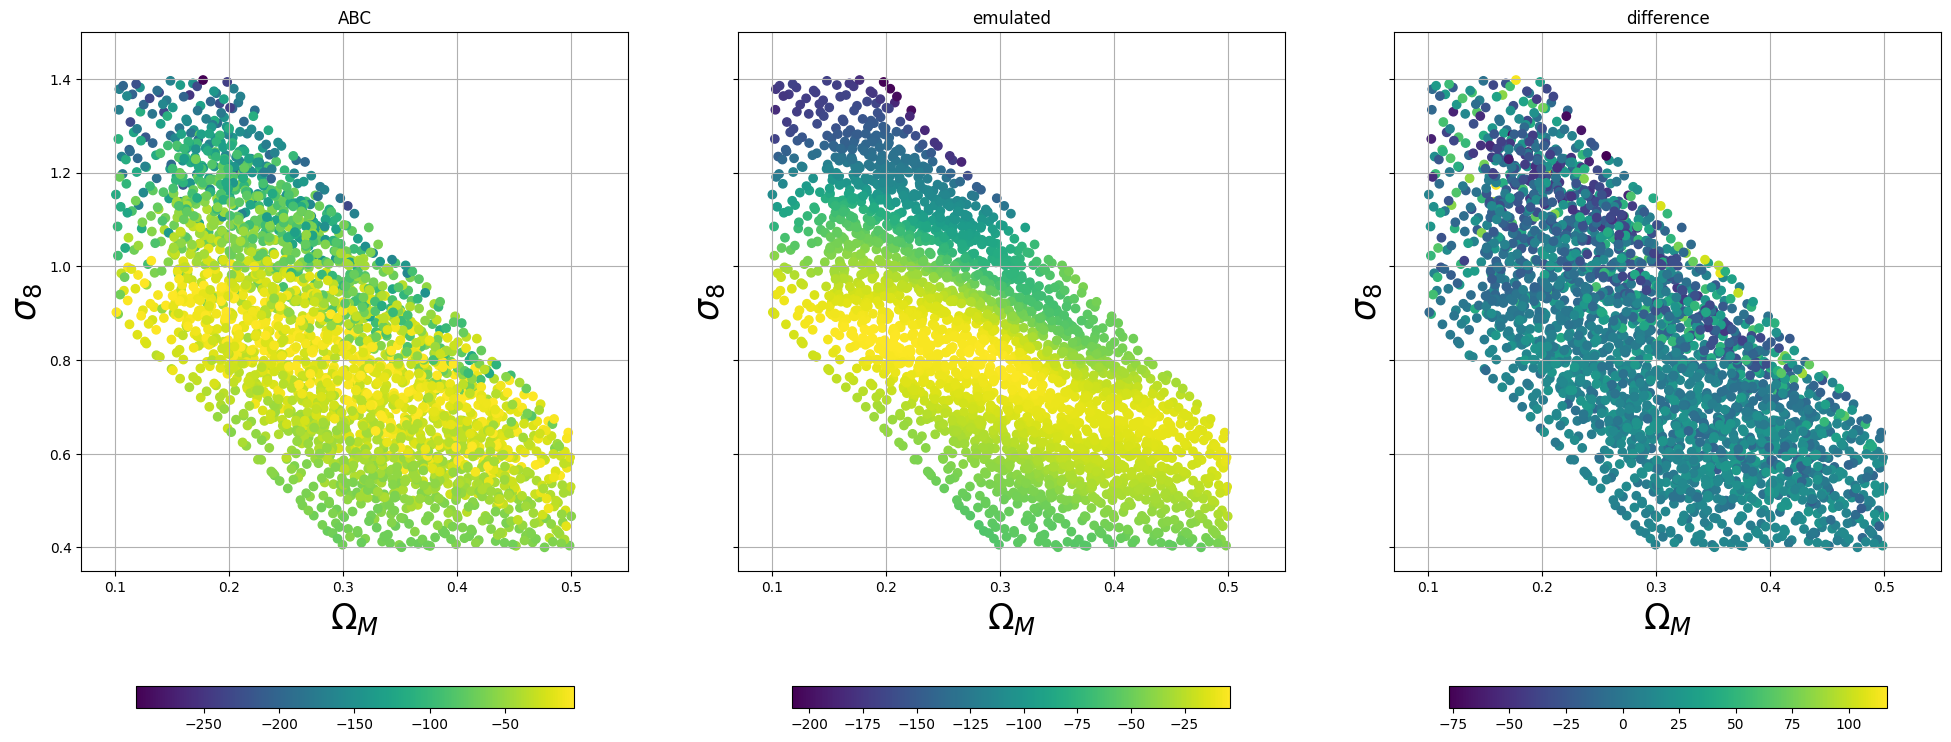

In [14]:
fig, ax = plt.subplots(figsize=(24,10), ncols=3, sharex=True, sharey=True)

# original
im = ax[0].scatter(Om, s8, c=np.log(abc_posterior))
fig.colorbar(im, orientation="horizontal", shrink=0.8, aspect=20, pad=0.15)
ax[0].set(xlim=(0.07, 0.55), ylim=(0.35, 1.5), title="ABC")
ax[0].set_xlabel("$\Omega_M$", fontsize=25)
ax[0].set_ylabel("$\sigma_8$", fontsize=25)
ax[0].grid(True)

# emulated
im = ax[1].scatter(Om, s8, c=np.log(pred_post))
fig.colorbar(im, orientation="horizontal", shrink=0.8, aspect=20, pad=0.15)
ax[1].set(xlim=(0.07, 0.55), ylim=(0.35, 1.5), title="emulated")
ax[1].set_xlabel("$\Omega_M$", fontsize=25)
ax[1].set_ylabel("$\sigma_8$", fontsize=25)
ax[1].grid(True)

# difference
im = ax[2].scatter(Om, s8, c=np.squeeze(np.log(pred_post)) - np.squeeze(np.log(abc_posterior)))
fig.colorbar(im, orientation="horizontal", shrink=0.8, aspect=20, pad=0.15)
ax[2].set(xlim=(0.07, 0.55), ylim=(0.35, 1.5), title="difference")
ax[2].set_xlabel("$\Omega_M$", fontsize=25)
ax[2].set_ylabel("$\sigma_8$", fontsize=25)
ax[2].grid(True)


# Run the MCMC

In [15]:
params = ["Om", "s8"]

In [16]:
from emcee import EnsembleSampler
from msfm.utils import prior, analysis, parameters
from trianglechain import TriangleChain

In [17]:
conf = analysis.load_config()

In [18]:
log_posterior = lambda X: prior.log_posterior(X, emu(X), params=params, conf=conf)

In [19]:
# emcee setup
np.random.seed(42)

nwalkers = 1024
ndim = len(params)
p0 = np.random.normal(loc=parameters.get_fiducials(params), scale=1e-3, size=(nwalkers, ndim))
print("Initial values in prior: ", np.all(prior.in_grid_prior(p0, params=params))) 

Initial values in prior:  True


In [20]:
# sample burn in
sampler = EnsembleSampler(nwalkers, ndim, log_posterior, vectorize=True)
state = sampler.run_mcmc(p0, 100)
sampler.reset()
# run the actual chain
sampler.run_mcmc(state, 1000, progress=True); 

100%|██████████| 1000/1000 [00:47<00:00, 20.87it/s]


In [21]:
samples = sampler.get_chain(flat=True) 

  0%|          | 0/1 [00:00<?, ?it/s]

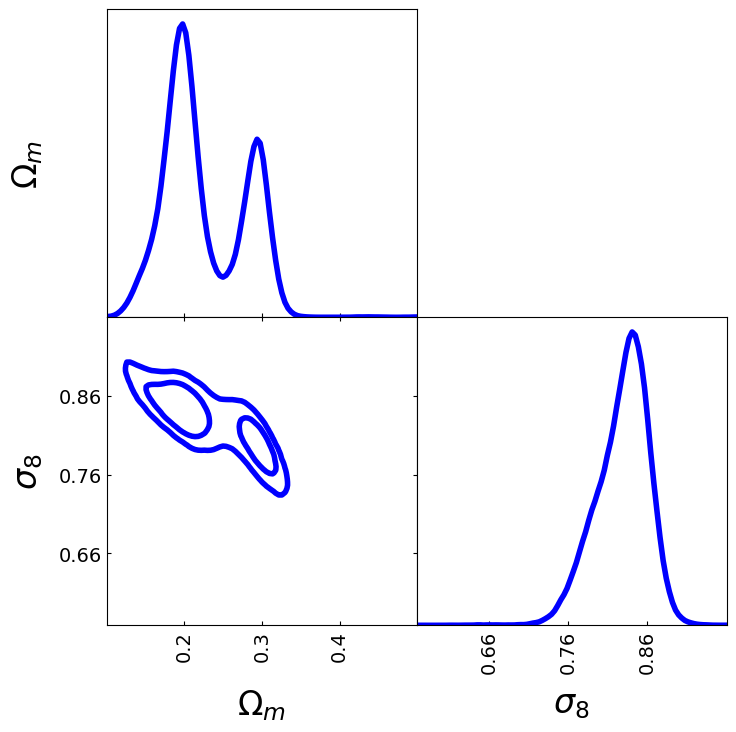

In [22]:
tri = TriangleChain(labels=[r'$\Omega_m$', r'$\sigma_8$'])
tri.contour_cl(samples);